## 1: IMPORTS & REPRODUCIBILITY SETUP

In [30]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, precision_recall_curve, 
    average_precision_score, matthews_corrcoef, 
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import label_binarize
import shap

# Fix random seeds for full reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configure paths for saved figures
OUTPUT_DIR = 'publication_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Environment initialized & dependencies verified.")

✅ Environment initialized & dependencies verified.


In [31]:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

## 2. DATASET LOADING & CONFIGURATION

In [32]:
DATA_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training'
TEST_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing'
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224
AUTOTUNE = tf.data.AUTOTUNE

def load_dataset(base_dir, subset=None, seed=123):
    if subset:
        return tf.keras.utils.image_dataset_from_directory(
            base_dir, validation_split=0.2, subset=subset, seed=seed,
            image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
        )
    return tf.keras.utils.image_dataset_from_directory(
        base_dir, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
    )

train_ds = load_dataset(DATA_DIR, subset="training")
val_ds = load_dataset(DATA_DIR, subset="validation")
test_ds = load_dataset(TEST_DIR)
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f"✅ Dataset loaded. Classes: {class_names}")

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
✅ Dataset loaded. Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. DATA PREPROCESSING & AUGMENTATION PIPELINE

In [33]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)\
                   .cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("✅ Data augmentation & pipeline configured.")

✅ Data augmentation & pipeline configured.


## 4. BASELINE MODEL TRAINING (SIMPLE CNN)

In [34]:
print("\n⏳ Training Baseline CNN...")
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES)
])

baseline_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
baseline_history = baseline_model.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)


⏳ Training Baseline CNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.3788 - loss: 2.1889 - val_accuracy: 0.5750 - val_loss: 0.9454
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7282 - loss: 0.6999 - val_accuracy: 0.6848 - val_loss: 0.8287
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8673 - loss: 0.3743 - val_accuracy: 0.6696 - val_loss: 1.0042
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9327 - loss: 0.2082 - val_accuracy: 0.6946 - val_loss: 0.9235
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9724 - loss: 0.0922 - val_accuracy: 0.6839 - val_loss: 1.2156


## 5. IMPROVED MODEL: TRANSFER LEARNING (EFFICIENTNETB0)

In [35]:
print("\n⏳ Training Improved Model (EfficientNetB0)...")
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
base_model.trainable = False  # Phase 1: Freeze

inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_v2 = tf.keras.Model(inputs, outputs)

# Phase 1: Train head
model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_phase1 = model_v2.fit(train_ds, validation_data=val_ds, epochs=5, verbose=1)

# Phase 2: Fine-tune
base_model.trainable = True
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_phase2 = model_v2.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[reduce_lr, early_stop], verbose=1)

print("✅ Improved model training complete.")


⏳ Training Improved Model (EfficientNetB0)...
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.6351 - loss: 0.9639 - val_accuracy: 0.7420 - val_loss: 0.6157
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8323 - loss: 0.4511 - val_accuracy: 0.7607 - val_loss: 0.5758
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8600 - loss: 0.3578 - val_accuracy: 0.8188 - val_loss: 0.4584
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8847 - loss: 0.3199 - val_accuracy: 0.8536 - val_loss: 0.3872
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.8933 - loss: 0.2861 - val_accuracy: 0.8161 - val_loss: 0.5128
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 164ms/step - accuracy: 0.7634 - loss: 0.6539 - val_accuracy: 0.8955 - val_loss: 0.3073 - learning_rate: 1.0000e-04
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9210 - loss: 0.2126 - val_accuracy: 0.8938 - val_loss: 0.2935 - learning_rate: 1.000

## 6. TRAINING HISTORY PLOTS (MANDATORY)

📊 Generating Training History Plots...


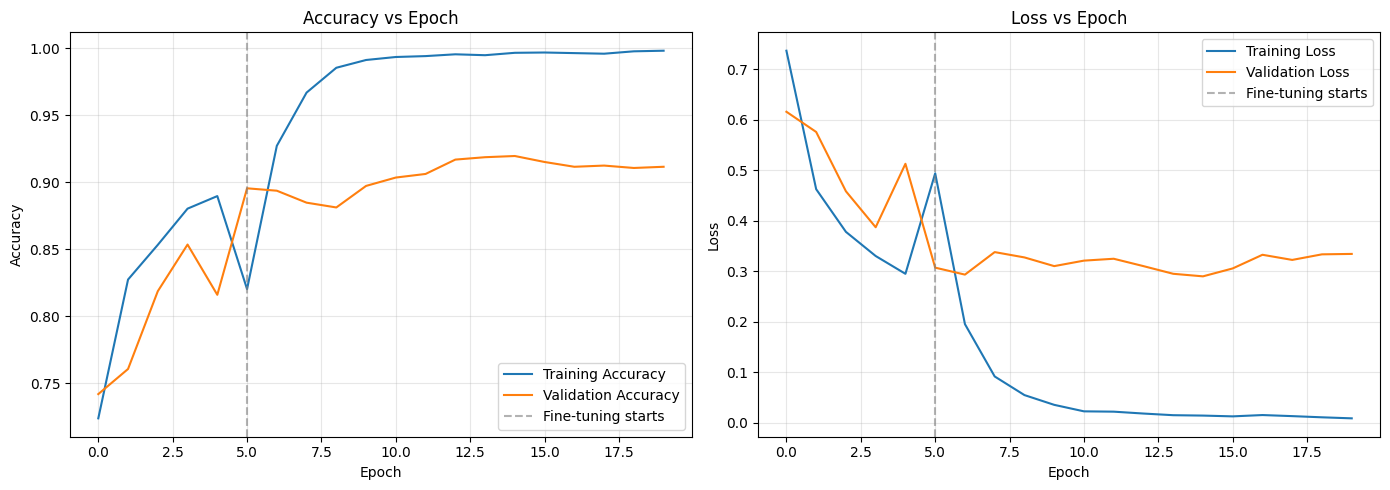

✅ Saved: 01_training_history.png


In [46]:
print("📊 Generating Training History Plots...")

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='Fine-tuning starts')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=5, color='gray', linestyle='--', alpha=0.6, label='Fine-tuning starts')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved: 01_training_history.png")

## 7. TEST EVALUATION & COMPREHENSIVE METRICS

In [47]:
print("📈 Evaluating on Test Set...")
y_true = []
y_pred = []
y_probs = []

test_imgs = []
test_labels = []
for images, labels in test_ds:
    preds = model_v2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_probs.extend(preds)
    test_imgs.append(images.numpy())
    test_labels.append(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)
test_imgs = np.concatenate(test_imgs)
test_labels = np.concatenate(test_labels)

# Inference Time
start = time.time()
_ = model_v2.predict(test_ds.take(3), verbose=0)  # Warmup
inf_start = time.time()
_ = model_v2.predict(test_ds.take(10), verbose=0)
inf_time_ms = ((time.time() - inf_start) / (10 * BATCH_SIZE)) * 1000

# Metrics
acc_val = (y_true == y_pred).mean()
f1_macro = f1_score(y_true, y_pred, average='macro')
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
mcc = matthews_corrcoef(y_true, y_pred)
total_params = model_v2.count_params()

# Specificity per class (One-vs-Rest)
tn = np.sum((y_pred != np.arange(NUM_CLASSES)[:, None]) & (y_true != np.arange(NUM_CLASSES)[:, None]), axis=1)
fp = np.sum((y_pred == np.arange(NUM_CLASSES)[:, None]) & (y_true != np.arange(NUM_CLASSES)[:, None]), axis=1)
specificity_per_class = tn / (tn + fp)
specificity_macro = np.mean(specificity_per_class)

print("\n📋 COMPREHENSIVE METRICS REPORT:")
print(f"Accuracy: {acc_val:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall (Sensitivity): {recall_macro:.4f}")
print(f"Macro Specificity: {specificity_macro:.4f}")
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"MCC (Matthews Correlation): {mcc:.4f}")
print(f"Inference Time: {inf_time_ms:.2f} ms/image")
print(f"Total Parameters: {total_params:,}")
print(classification_report(y_true, y_pred, target_names=class_names))

📈 Evaluating on Test Set...

📋 COMPREHENSIVE METRICS REPORT:
Accuracy: 0.8825
Macro Precision: 0.8877
Macro Recall (Sensitivity): 0.8825
Macro Specificity: 0.9608
Macro F1-Score: 0.8794
MCC (Matthews Correlation): 0.8469
Inference Time: 0.80 ms/image
Total Parameters: 4,416,039
              precision    recall  f1-score   support

      glioma       0.94      0.79      0.86       400
  meningioma       0.90      0.76      0.82       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.86      0.99      0.92       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



## 8. SCIENTIFIC VISUALIZATIONS (CONFUSION MATRIX, ROC-AUC, PR CURVE)

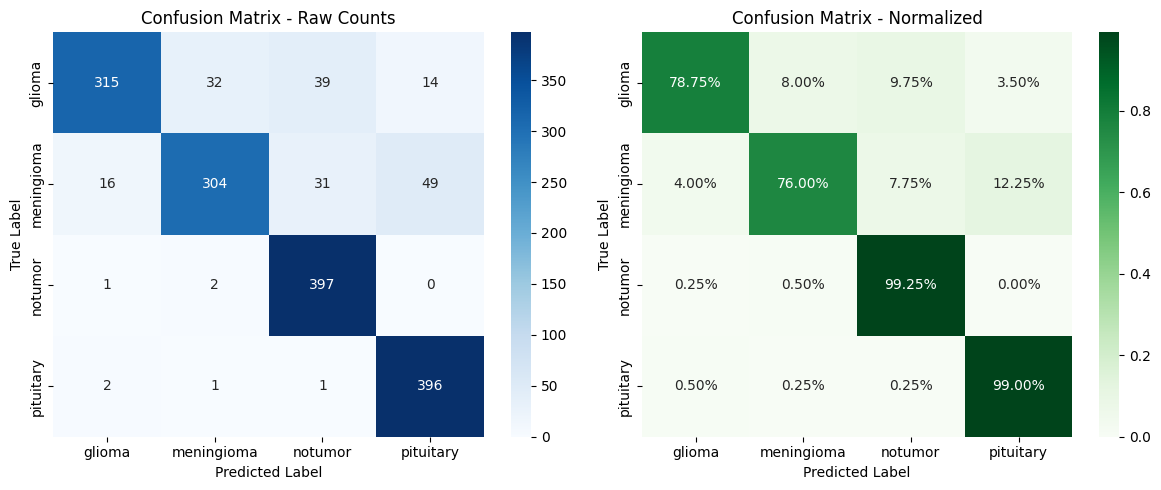

In [38]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Raw Counts')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.subplot(1, 2, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Normalized')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

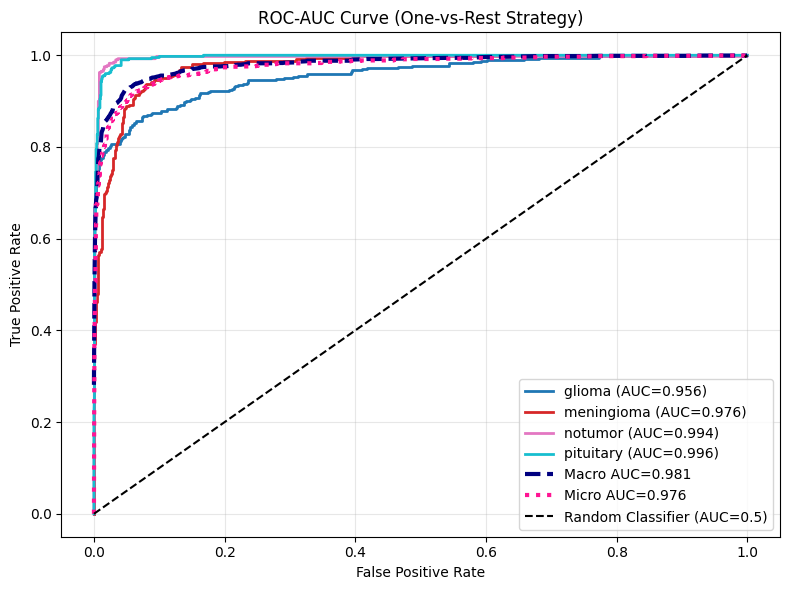

In [39]:
# ROC-AUC Curve
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES): mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= NUM_CLASSES
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC={roc_auc[i]:.3f})')
plt.plot(fpr["macro"], tpr["macro"], linestyle='--', color='navy', lw=3, label=f'Macro AUC={roc_auc["macro"]:.3f}')
plt.plot(fpr["micro"], tpr["micro"], linestyle=':', color='deeppink', lw=3, label=f'Micro AUC={roc_auc["micro"]:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve (One-vs-Rest Strategy)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_roc_auc.png', dpi=300, bbox_inches='tight')
plt.show()

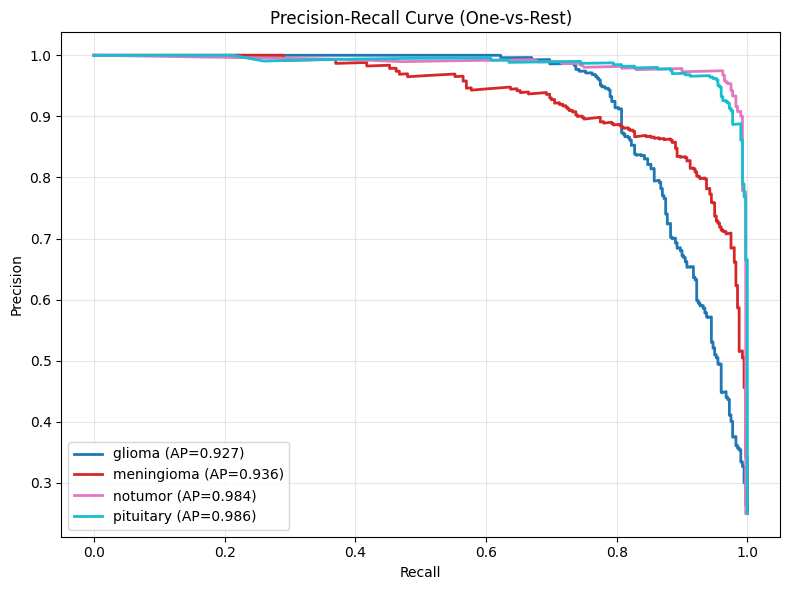

In [40]:
# PR Curve
precision = dict(); recall = dict(); ap = dict()
for i in range(NUM_CLASSES):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap[i] = average_precision_score(y_true_bin[:, i], y_probs[:, i])

plt.figure(figsize=(8, 6))
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2, label=f'{class_names[i]} (AP={ap[i]:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (One-vs-Rest)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. PREPROCESSING COMPARISON & FAILURE ANALYSIS

🖼️ Generating Preprocessing & Failure Analysis...
Found 5600 files belonging to 4 classes.
Using 4480 files for training.


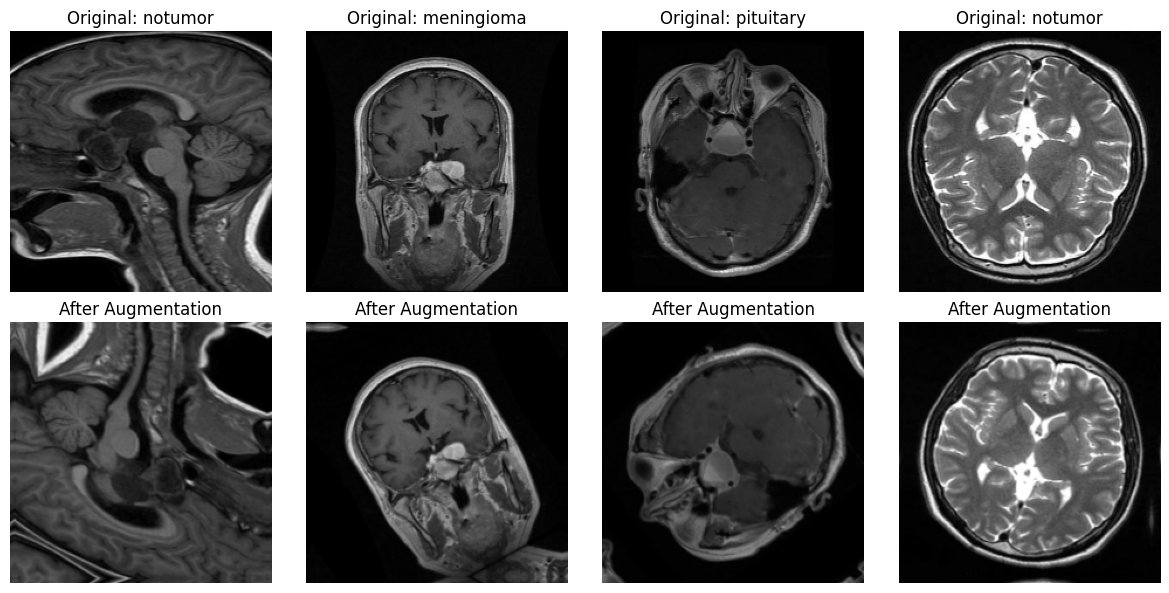

In [41]:
print("🖼️ Generating Preprocessing & Failure Analysis...")

# ✅ FIXED: Added validation_split=0.2 to match subset="training"
sample_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, subset="training", seed=123, validation_split=0.2,
    image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=4
)
sample_x, sample_y = next(iter(sample_ds))
aug_x = data_augmentation(sample_x, training=True)

plt.figure(figsize=(12, 6))
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_x[i].numpy().astype('uint8'))
    plt.title(f'Original: {class_names[sample_y[i]]}')
    plt.axis('off')
    plt.subplot(2, 4, i+5)
    plt.imshow(aug_x[i].numpy().astype('uint8'))
    plt.title('After Augmentation')
    plt.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show() # ✅ ADDED: Shows chart inline

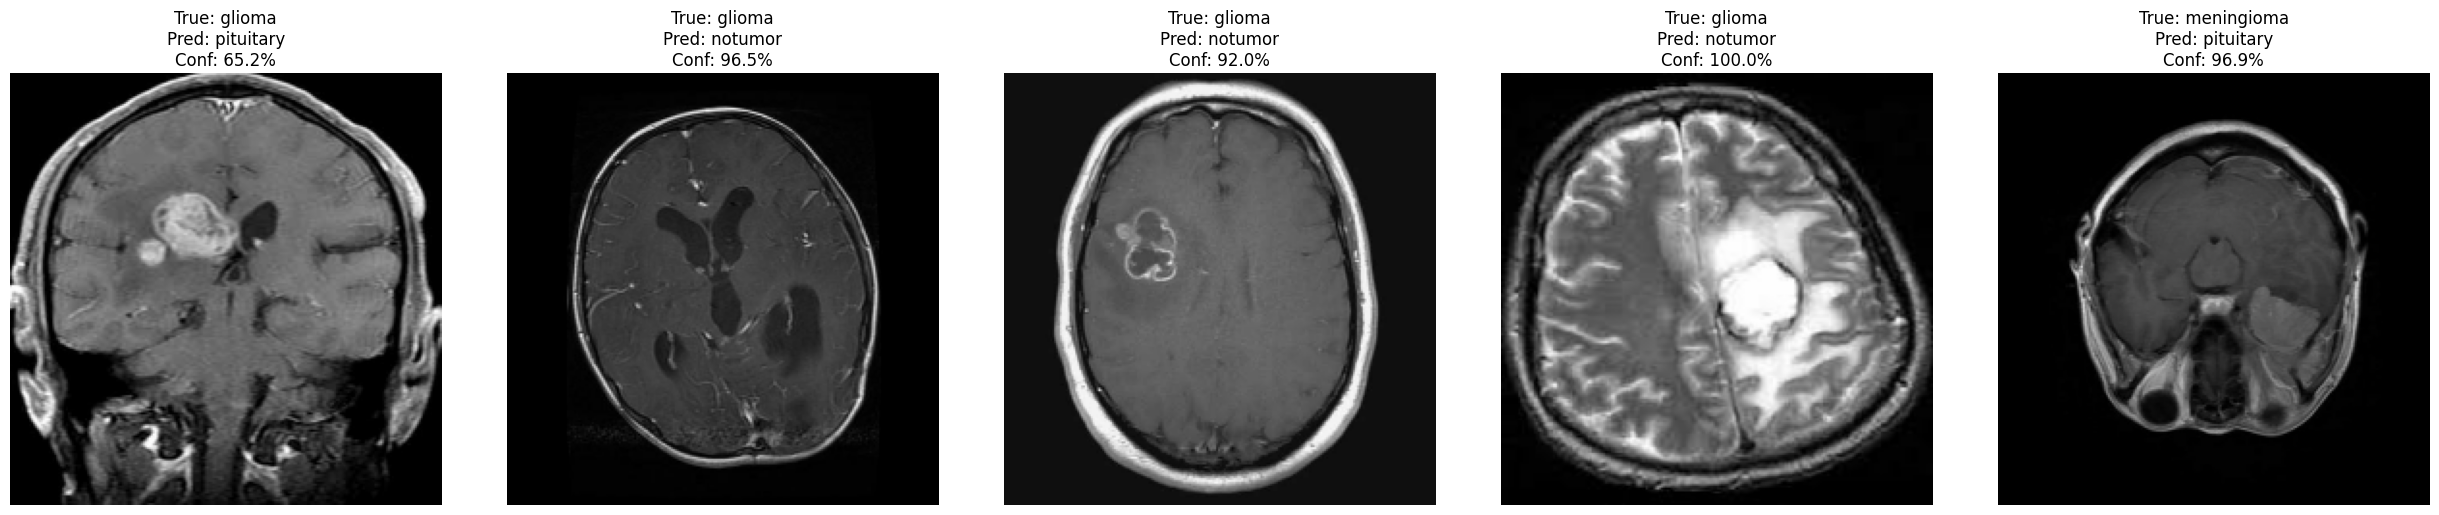

In [42]:
# Failure Analysis
misclassified = []
for imgs, labs in test_ds:
    preds = model_v2.predict(imgs, verbose=0)
    for i in range(len(labs)):
        if labs[i] != np.argmax(preds[i]) and len(misclassified) < 5:
            misclassified.append({
                'img': imgs[i].numpy(), 'true': class_names[labs[i]], 
                'pred': class_names[np.argmax(preds[i])], 'conf': np.max(preds[i]) * 100
            })

if misclassified:
    plt.figure(figsize=(5 * len(misclassified), 5))
    for idx, item in enumerate(misclassified):
        plt.subplot(1, len(misclassified), idx+1)
        plt.imshow(item['img'].astype('uint8'))
        plt.axis('off')
        plt.title(f"True: {item['true']}\nPred: {item['pred']}\nConf: {item['conf']:.1f}%")
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/06_failure_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

## 10. EXPLAINABLE AI (XAI): GRAD-CAM, SALIENCY, SHAP

In [1]:
# import shap
 
# # ── helpers ──────────────────────────────────────────────────────────────────
 
# def _resize_map(arr_2d, height, width):
#     """
#     Resize a 2-D numpy array (H, W) to (height, width) using tf.image.resize.
#     tf.image.resize requires shape (batch, H, W, C), so we add/remove those dims.
#     """
#     arr = tf.constant(arr_2d[np.newaxis, ..., np.newaxis], dtype=tf.float32)
#     arr = tf.image.resize(arr, (height, width))
#     return arr.numpy()[0, ..., 0]          # back to (H, W)
 
 
# def _normalize(arr):
#     """Min-max normalise to [0, 1], safe against constant maps."""
#     lo, hi = arr.min(), arr.max()
#     return (arr - lo) / (hi - lo + 1e-8)
 
 
# def _overlay_heatmap(base_img_uint8, heatmap_01, alpha=0.45, colormap=cm.jet):
#     """
#     Blend a [0,1] heatmap onto a uint8 RGB image.
#     Returns a uint8 RGB image.
#     """
#     colored = colormap(heatmap_01)[..., :3]          # (H,W,3) float [0,1]
#     base    = base_img_uint8.astype(np.float32) / 255.0
#     blended = (1 - alpha) * base + alpha * colored
#     return (np.clip(blended, 0, 1) * 255).astype(np.uint8)
 
 
# # ── core XAI function ────────────────────────────────────────────────────────
 
# def compute_gradcam_and_saliency(model, img_tensor, target_class_idx):
#     """
#     Computes Grad-CAM heatmap and vanilla saliency map for one image.
 
#     Parameters
#     ----------
#     model           : compiled tf.keras.Model
#     img_tensor      : float32 tensor, shape (1, H, W, 3), pixel values [0, 255]
#     target_class_idx: int – class index to explain
 
#     Returns
#     -------
#     heatmap  : np.ndarray (H, W), values in [0, 1]
#     saliency : np.ndarray (H, W), values in [0, 1]
#     """
#     # ── find last Conv2D (searches nested sub-models, e.g. EfficientNet) ──
#     last_conv = None
#     for layer in reversed(model.layers):
#         if hasattr(layer, 'layers'):                            # nested model
#             for sub in reversed(layer.layers):
#                 if isinstance(sub, tf.keras.layers.Conv2D):
#                     last_conv = sub
#                     break
#         elif isinstance(layer, tf.keras.layers.Conv2D):
#             last_conv = layer
#         if last_conv is not None:
#             break
 
#     if last_conv is None:
#         raise ValueError("No Conv2D layer found in model.")
 
#     # ── Grad-CAM ──────────────────────────────────────────────────────────
#     grad_model = tf.keras.Model(
#         inputs=model.input,                                     # Keras 3-safe
#         outputs=[last_conv.output, model.output]
#     )
 
#     with tf.GradientTape() as tape:
#         conv_out, preds = grad_model(img_tensor, training=False)
#         score = preds[:, target_class_idx]
 
#     grads       = tape.gradient(score, conv_out)               # (1, h, w, C)
#     pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))        # (C,)
#     heatmap_raw = tf.reduce_sum(
#         tf.squeeze(conv_out, axis=0) * pooled, axis=-1
#     )                                                           # (h, w)
#     heatmap_raw = tf.maximum(heatmap_raw, 0).numpy()           # ReLU
#     heatmap     = _normalize(heatmap_raw)
 
#     # ── Saliency ──────────────────────────────────────────────────────────
#     img_var = tf.Variable(img_tensor, dtype=tf.float32)
#     with tf.GradientTape() as tape:
#         tape.watch(img_var)
#         out = model(img_var, training=False)
#         cls_score = out[:, target_class_idx]
 
#     input_grads = tape.gradient(cls_score, img_var)            # (1, H, W, 3)
#     saliency    = tf.reduce_max(
#         tf.abs(tf.squeeze(input_grads, axis=0)), axis=-1
#     ).numpy()                                                   # (H, W)
#     saliency    = _normalize(saliency)
 
#     return heatmap, saliency

In [44]:
# # ── helpers ──────────────────────────────────────────────────────────────────
 
# def _resize_map(arr_2d, height, width):
#     """
#     Resize a 2-D numpy array (H, W) to (height, width) using tf.image.resize.
#     tf.image.resize requires shape (batch, H, W, C), so we add/remove those dims.
#     """
#     arr = tf.constant(arr_2d[np.newaxis, ..., np.newaxis], dtype=tf.float32)
#     arr = tf.image.resize(arr, (height, width))
#     return arr.numpy()[0, ..., 0]          # back to (H, W)
 
 
# def _normalize(arr):
#     """Min-max normalise to [0, 1], safe against constant maps."""
#     lo, hi = arr.min(), arr.max()
#     return (arr - lo) / (hi - lo + 1e-8)
 
 
# def _overlay_heatmap(base_img_uint8, heatmap_01, alpha=0.45, colormap=cm.jet):
#     """
#     Blend a [0,1] heatmap onto a uint8 RGB image.
#     Returns a uint8 RGB image.
#     """
#     colored = colormap(heatmap_01)[..., :3]          # (H,W,3) float [0,1]
#     base    = base_img_uint8.astype(np.float32) / 255.0
#     blended = (1 - alpha) * base + alpha * colored
#     return (np.clip(blended, 0, 1) * 255).astype(np.uint8)
 
 
# # ── core XAI function ────────────────────────────────────────────────────────
 
# def compute_gradcam_and_saliency(model, img_tensor, target_class_idx):
#     """
#     Computes Grad-CAM heatmap and vanilla saliency map for one image.
 
#     Parameters
#     ----------
#     model           : compiled tf.keras.Model
#     img_tensor      : float32 tensor, shape (1, H, W, 3), pixel values [0, 255]
#     target_class_idx: int – class index to explain
 
#     Returns
#     -------
#     heatmap  : np.ndarray (H, W), values in [0, 1]
#     saliency : np.ndarray (H, W), values in [0, 1]
#     """
#     # ── find last Conv2D (searches nested sub-models, e.g. EfficientNet) ──
#     last_conv = None
#     for layer in reversed(model.layers):
#         if hasattr(layer, 'layers'):                            # nested model
#             for sub in reversed(layer.layers):
#                 if isinstance(sub, tf.keras.layers.Conv2D):
#                     last_conv = sub
#                     break
#         elif isinstance(layer, tf.keras.layers.Conv2D):
#             last_conv = layer
#         if last_conv is not None:
#             break
 
#     if last_conv is None:
#         raise ValueError("No Conv2D layer found in model.")
 
#     # ── Grad-CAM ──────────────────────────────────────────────────────────
#     grad_model = tf.keras.Model(
#         inputs=model.input,                                     # Keras 3-safe
#         outputs=[last_conv.output, model.output]
#     )
 
#     with tf.GradientTape() as tape:
#         conv_out, preds = grad_model(img_tensor, training=False)
#         score = preds[:, target_class_idx]
 
#     grads       = tape.gradient(score, conv_out)               # (1, h, w, C)
#     pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))        # (C,)
#     heatmap_raw = tf.reduce_sum(
#         tf.squeeze(conv_out, axis=0) * pooled, axis=-1
#     )                                                           # (h, w)
#     heatmap_raw = tf.maximum(heatmap_raw, 0).numpy()           # ReLU
#     heatmap     = _normalize(heatmap_raw)
 
#     # ── Saliency ──────────────────────────────────────────────────────────
#     img_var = tf.Variable(img_tensor, dtype=tf.float32)
#     with tf.GradientTape() as tape:
#         tape.watch(img_var)
#         out = model(img_var, training=False)
#         cls_score = out[:, target_class_idx]
 
#     input_grads = tape.gradient(cls_score, img_var)            # (1, H, W, 3)
#     saliency    = tf.reduce_max(
#         tf.abs(tf.squeeze(input_grads, axis=0)), axis=-1
#     ).numpy()                                                   # (H, W)
#     saliency    = _normalize(saliency)
 
#     return heatmap, saliency


# print("🧠 [Section 10] Generating Grad-CAM & Saliency visualisations…")
 
# # ── pick samples ──────────────────────────────────────────────────────────
# correct_idxs, incorrect_idxs = [], []
# for i in range(len(y_true)):
#     if y_true[i] == y_pred[i]   and len(correct_idxs)   < 6: correct_idxs.append(i)
#     if y_true[i] != y_pred[i]   and len(incorrect_idxs) < 2: incorrect_idxs.append(i)
#     if len(correct_idxs) >= 6 and len(incorrect_idxs) >= 2:
#         break
 
# sample_idxs = (correct_idxs[:6] + incorrect_idxs[:2])[:8]
# n_samples   = len(sample_idxs)
 
# # ── figure: 3 columns (Original | Grad-CAM | Saliency) ──────────────────
# fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4 * n_samples))
# col_titles = ["Original Image", "Grad-CAM Overlay", "Saliency Map"]
# for col, title in enumerate(col_titles):
#     axes[0, col].set_title(title, fontsize=13, fontweight='bold', pad=10)
 
# for row, idx in enumerate(sample_idxs):
#     raw_img    = test_imgs[idx]                                 # (H, W, 3) float
#     img_tensor = tf.expand_dims(
#         tf.constant(raw_img, dtype=tf.float32), axis=0
#     )                                                           # (1, H, W, 3)
#     target_cls = int(y_pred[idx])
 
#     heatmap, saliency = compute_gradcam_and_saliency(model_v2, img_tensor, target_cls)
 
#     # resize maps from conv-feature resolution → IMG_HEIGHT × IMG_WIDTH
#     heatmap  = _resize_map(heatmap,  IMG_HEIGHT, IMG_WIDTH)
#     saliency = _resize_map(saliency, IMG_HEIGHT, IMG_WIDTH)
 
#     gc_overlay  = _overlay_heatmap(raw_img.astype(np.uint8), heatmap,  colormap=cm.jet)
#     sal_overlay = _overlay_heatmap(raw_img.astype(np.uint8), saliency, colormap=cm.hot)
 
#     status = "✅ CORRECT" if y_true[idx] == y_pred[idx] else "❌ WRONG"
#     row_label = (
#         f"{status}\n"
#         f"True: {class_names[y_true[idx]]}\n"
#         f"Pred: {class_names[y_pred[idx]]}"
#     )
 
#     # col 0 – original
#     axes[row, 0].imshow(raw_img.astype(np.uint8))
#     axes[row, 0].set_ylabel(row_label, fontsize=9, rotation=0,
#                             labelpad=110, va='center')
 
#     # col 1 – Grad-CAM
#     axes[row, 1].imshow(gc_overlay)
 
#     # col 2 – Saliency
#     axes[row, 2].imshow(sal_overlay)
 
#     for col in range(3):
#         axes[row, col].axis('off')
 
# plt.suptitle("Grad-CAM & Saliency Map — Correct vs Misclassified Samples",
#              fontsize=15, fontweight='bold', y=1.01)
# plt.tight_layout()
# save_path = os.path.join(OUTPUT_DIR, '07_xai_gradcam_saliency.png')
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
# plt.show()
# print(f"✅ Saved: {save_path}")

In [45]:
# print("\n🔍 [Section 11] Generating SHAP visualisations…")
 
# # ── prepare inputs (normalise to [0, 1] — what the model expects post-Rescaling) ──
# # If your model has a Rescaling(1/255) layer, pass raw [0,255] pixels.
# # EfficientNetB0 with a Rescaling layer → pass raw pixels.
# background   = tf.constant(test_imgs[:50],  dtype=tf.float32)    # (50, H, W, 3)
# explain_imgs = tf.constant(                                        # 1 correct + 1 wrong
#     test_imgs[[correct_idxs[0], incorrect_idxs[0]]],
#     dtype=tf.float32
# )                                                                  # (2, H, W, 3)
 
# # ── build explainer ──────────────────────────────────────────────────────
# # GradientExplainer is the correct choice for deep image models in TF/Keras.
# # DeepExplainer frequently breaks on non-standard layer sequences.
# explainer   = shap.GradientExplainer(model_v2, background)
# shap_values = explainer.shap_values(explain_imgs)
# # shap_values: list of NUM_CLASSES arrays, each (2, H, W, 3)
 
# # ── 11-A  Global: mean |SHAP| across all classes ─────────────────────────
# # For image models the "global" view is best shown as a pixel-importance map.
# # We average absolute SHAP values over all classes and both samples.
# mean_abs_shap = np.mean(
#     [np.abs(sv) for sv in shap_values], axis=(0, 1)
# )                                                                  # (H, W, 3)
# mean_abs_shap_gray = mean_abs_shap.mean(axis=-1)                  # (H, W)
# mean_abs_shap_gray = _normalize(mean_abs_shap_gray)
 
# fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# axes[0].imshow(
#     _overlay_heatmap(
#         test_imgs[correct_idxs[0]].astype(np.uint8),
#         _resize_map(mean_abs_shap_gray, IMG_HEIGHT, IMG_WIDTH),
#         alpha=0.6, colormap=cm.inferno
#     )
# )
# axes[0].set_title("SHAP Global Feature Importance\n(mean |SHAP| across all classes & samples)",
#                   fontsize=11, fontweight='bold')
# axes[0].axis('off')
 
# # colour bar only
# cb_img = np.linspace(0, 1, 256).reshape(256, 1)
# axes[1].imshow(cb_img, aspect='auto', cmap='inferno',
#                extent=[0, 1, 0, 1], origin='lower')
# axes[1].set_xlabel("Normalised |SHAP| value", fontsize=10)
# axes[1].set_yticks([])
# axes[1].set_title("Colour Scale", fontsize=11)
 
# plt.suptitle("SHAP — Global Feature Importance Map", fontsize=13, fontweight='bold')
# plt.tight_layout()
# save_path_global = os.path.join(OUTPUT_DIR, '08_shap_global.png')
# plt.savefig(save_path_global, dpi=300, bbox_inches='tight')
# plt.show()
# print(f"✅ Saved: {save_path_global}")
 
# # ── 11-B  Local: per-sample, per-class SHAP image_plot ───────────────────
# # shap.image_plot is the ONLY correct SHAP visualisation for image inputs.
# # force_plot requires 1-D tabular features and will crash on (H,W,3) arrays.
 
# sample_labels = [
#     f"CORRECT — True: {class_names[y_true[correct_idxs[0]]]} | "
#     f"Pred: {class_names[y_pred[correct_idxs[0]]]}",
#     f"WRONG   — True: {class_names[y_true[incorrect_idxs[0]]]} | "
#     f"Pred: {class_names[y_pred[incorrect_idxs[0]]]}",
# ]
 
# for i, label in enumerate(sample_labels):
#     # shap_values is list[NUM_CLASSES] of (N, H, W, 3)
#     # For image_plot pass list of (1, H, W, 3) arrays — one per class
#     sv_single = [sv[i:i+1] for sv in shap_values]              # list[(1,H,W,3)]
#     img_single = explain_imgs[i:i+1].numpy()                   # (1, H, W, 3)
 
#     fig = plt.figure(figsize=(4 * NUM_CLASSES, 4))
#     # shap.image_plot renders directly; capture the figure it creates
#     shap.image_plot(
#         sv_single,
#         img_single,
#         labels=class_names,
#         show=False
#     )
#     plt.suptitle(f"SHAP Local Explanation\n{label}",
#                  fontsize=11, fontweight='bold', y=1.04)
 
#     save_path_local = os.path.join(OUTPUT_DIR, f'09_shap_local_{i+1}.png')
#     plt.savefig(save_path_local, dpi=300, bbox_inches='tight')
#     plt.show()
#     print(f"✅ Saved: {save_path_local}")
 
# print("\n✅ All XAI visualisations complete.")
# print("   Saved files:")
# for fname in ['07_xai_gradcam_saliency.png', '08_shap_global.png',
#               '09_shap_local_1.png', '09_shap_local_2.png']:
#     print(f"   • {OUTPUT_DIR}/{fname}")
 